# Polikliniek – simulatiemodel voor wachttijd, uitloop en werkbaarheid

Dit notebook is de **technische onderbouwing** bij het adviesrapport “WFM in de polikliniek”.
Het laat zien **hoe** de scenario’s A/B/C zijn doorgerekend met een reproduceerbaar simulatiemodel.

**Leeswijzer**
- We modelleren een polikliniekdag met consulten en expliciete admin-blokken.
- Variatie (consultduur, no-show, te laat, admin) wordt expliciet gesimuleerd.
- Scenario’s verschillen uitsluitend in **bufferstrategie** (A strak, B uniform, C slim).
- Resultaten zijn **indicatief** (gesimuleerde data): doel is *inzicht in het denkkader*.

> De kernvraag is: hoe organiseer je inzet zodat wachttijd beheersbaar blijft én de werkdag voorspelbaar/werkbaar is?


## 1. Modeloverzicht (conceptueel)

We simuleren per resource een dag-tijdlijn:

1. **Planned schedule**: consultblokken (N/C/V) met direct erna een gepland adminblok (A), en optioneel extra bufferblok (B).
2. **Realisatie**: consulten kunnen uitlopen, mensen kunnen te laat komen of niet verschijnen.
3. **Admin-backlog**: admin ontstaat na consult en wordt idealiter in het A-blok gedaan; wat niet past schuift door.
4. **Lunch**: consultstarts in lunch worden vermeden; admin in lunch is optioneel (standaard niet).

We rapporteren zowel **patiëntimpact** (wachttijd) als **personeelsimpact** (admin displacement/backlog, lunch onder minimum).


In [1]:
# Core imports
from __future__ import annotations

import os
# Ensure matplotlib can write its cache/config in this project folder
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".mplconfig"))

from dataclasses import dataclass, field
from collections import deque
from typing import Dict, List, Tuple, Optional, Set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Parameters en aannames

Alle aannames staan in `ModelConfig`. Scenario’s worden gemaakt met `make_config("A"|"B"|"C")`.


In [2]:
@dataclass(frozen=True)
class ModelConfig:
    """Model- en scenario-instellingen voor de polikliniek-simulatie.

    Alles is in minuten (minuten sinds middernacht voor absolute tijden).
    """
    # Dagindeling
    day_start: int = 8 * 60
    lunch_start: int = 12 * 60
    lunch_end: int = 12 * 60 + 30
    day_end: int = 17 * 60
    min_lunch: int = 15

    # Resources (homogeen: ieder resource kan ieder consulttype)
    resources: Tuple[str, ...] = ("R1", "R2", "R3")

    # Slotlengtes (planned schedule; per block type)
    slot_minutes: Dict[str, int] = field(default_factory=lambda: {"N": 25, "C": 15, "V": 10, "A": 5, "B": 5})

    # Verwachte mix (per resource per dag; totaal = som(base_counts))
    base_counts: Dict[str, int] = field(default_factory=lambda: {"N": 6, "C": 10, "V": 4})

    # Fricties in instroom
    noshow_p: Dict[str, float] = field(default_factory=lambda: {"N": 0.04, "C": 0.06, "V": 0.03})
    late_p: Dict[str, float] = field(default_factory=lambda: {"N": 0.10, "C": 0.12, "V": 0.08})

    # Buffer in planning (tussen blocks, los van B-blokken)
    buffer_between_blocks: int = 0

    # Late minuten (gegeven: te laat), truncated normal parameters
    late_loc: float = 6.0
    late_scale: float = 4.0
    late_min: int = 1
    late_max: int = 25

    # Consultduur-variatie (lognormale factor rond 1.0)
    consult_sigma: float = 0.25
    consult_clip_min_factor: float = 0.5
    consult_clip_max_factor: float = 2.5

    # Admin requirement: max(min, base + pct * consult_minutes)
    admin_min: float = 5.0
    admin_base: float = 5.0
    admin_pct: float = 0.05

    # Variatie in admin requirement (lognormale factor rond 1.0)
    admin_sigma: float = 0.45
    admin_clip_min_factor: float = 0.3
    admin_clip_max_factor: float = 3.0

    # Lunchgedrag
    admin_in_lunch_allowed: bool = False

    # KPI threshold (alleen gebruikt in illustratieve plots/tellingen)
    wait_threshold: float = 15.0

    # Scenario-knoppen (A/B/C)
    scenario_name: str = "A"
    fixed_buffer_after_A: bool = False          # Scenario B (altijd B na A)
    smart_buffer_positions: Optional[Set[int]] = None  # Scenario C (subset; 0-based consult index)


def make_config(scenario: str = "A", *, buffer_between_blocks: int = 0) -> ModelConfig:
    """Convenience factory voor scenario A/B/C.

    - A: strak (geen B na A; alleen A-blok direct na consult)
    - B: uniform werkbaar (altijd B na A)
    - C: slimme buffer (B na A op geselecteerde consultposities)
    """
    scenario = scenario.upper()
    if scenario == "A":
        return ModelConfig(scenario_name="A", fixed_buffer_after_A=False, smart_buffer_positions=None,
                           buffer_between_blocks=buffer_between_blocks)
    if scenario == "B":
        return ModelConfig(scenario_name="B", fixed_buffer_after_A=True, smart_buffer_positions=None,
                           buffer_between_blocks=buffer_between_blocks)
    if scenario == "C":
        return ModelConfig(scenario_name="C", fixed_buffer_after_A=False, smart_buffer_positions=set(),
                           buffer_between_blocks=buffer_between_blocks)
    raise ValueError(f"Unknown scenario: {scenario!r}")


## 3. Variatie (stochastiek)

- **No-show / te laat**: per afspraaktype met eigen kans.
- **Te laat minuten**: truncated normal (rejection sampling).
- **Consultduur**: lognormale factor rond de geplande slotduur.
- **Admin requirement**: verwacht op basis van consultduur + lognormale variatie.


In [3]:
# ----------------------------
# Stochastiek (met expliciete RNG voor reproduceerbaarheid)
# ----------------------------

def sample_counts(cfg: ModelConfig, rng: np.random.Generator) -> Dict[str, int]:
    """Sample aantallen N/C/V met vaste totalen, maar variabele verdeling.

    Verwachtingswaarde blijft gelijk aan cfg.base_counts.
    """
    base = cfg.base_counts
    total = int(sum(base.values()))
    p = np.array([base["N"], base["C"], base["V"]], dtype=float) / total
    n, c, v = rng.multinomial(total, p)
    return {"N": int(n), "C": int(c), "V": int(v)}


def shuffled_consult_sequence(cfg: ModelConfig, rng: np.random.Generator) -> List[str]:
    counts = sample_counts(cfg, rng)
    seq = ["N"] * counts["N"] + ["C"] * counts["C"] + ["V"] * counts["V"]
    rng.shuffle(seq)
    return seq


def late_minutes(cfg: ModelConfig, rng: np.random.Generator) -> int:
    """Minutes late GIVEN late=True. Truncated normal via rejection sampling."""
    x = rng.normal(loc=cfg.late_loc, scale=cfg.late_scale)
    while (x < cfg.late_min) or (x > cfg.late_max):
        x = rng.normal(loc=cfg.late_loc, scale=cfg.late_scale)
    return int(np.rint(x))


def realized_consult_minutes(cfg: ModelConfig, rng: np.random.Generator, planned_slot: int) -> float:
    """Realized consult length as lognormal multiplier around the planned slot."""
    sigma = cfg.consult_sigma
    mu = -0.5 * sigma**2  # mean factor ~1.0
    factor = rng.lognormal(mean=mu, sigma=sigma)
    minutes = planned_slot * factor
    return float(np.clip(minutes,
                         cfg.consult_clip_min_factor * planned_slot,
                         cfg.consult_clip_max_factor * planned_slot))


def expected_admin_minutes(cfg: ModelConfig, consult_minutes: float) -> float:
    return max(cfg.admin_min, cfg.admin_base + cfg.admin_pct * consult_minutes)


def required_admin_minutes(cfg: ModelConfig, rng: np.random.Generator, consult_minutes: float) -> float:
    """Admin requirement as noisy multiplier around expected admin."""
    mean = expected_admin_minutes(cfg, consult_minutes)
    sigma = cfg.admin_sigma
    mu = -0.5 * sigma**2
    factor = rng.lognormal(mean=mu, sigma=sigma)
    factor = float(np.clip(factor, cfg.admin_clip_min_factor, cfg.admin_clip_max_factor))
    return float(max(0.0, mean * factor))


## 4. Planned schedule

De planning is een template: we plannen N/C/V consulten, daarna altijd een A-blok, en in scenario B/C (soms) een B-blok.


In [4]:
# ----------------------------
# Planning (planned schedule) voor één dag
# ----------------------------

PlannedBlock = Tuple[int, str, int]  # (planned_start, block_type, slot_length)


def build_planned_schedule_for_resource(cfg: ModelConfig, rng: np.random.Generator) -> List[PlannedBlock]:
    """Maak de geplande blocks voor één resource (N/C/V consulten, met A en evt B).

    Belangrijk: dit is de *template* waarop de realisatie wordt gesimuleerd.
    """
    t = cfg.day_start
    schedule: List[PlannedBlock] = []

    consult_seq = shuffled_consult_sequence(cfg, rng)
    consult_index = 0

    for appt_type in consult_seq:
        consult_len = cfg.slot_minutes[appt_type]

        # Start niet in lunch
        if cfg.lunch_start <= t < cfg.lunch_end:
            t = cfg.lunch_end

        if t + consult_len > cfg.day_end:
            break

        # Consult
        schedule.append((t, appt_type, consult_len))
        t = t + consult_len + cfg.buffer_between_blocks

        # Direct admin-blok A
        a_len = cfg.slot_minutes["A"]
        if cfg.lunch_start <= t < cfg.lunch_end:
            t = cfg.lunch_end
        if t + a_len > cfg.day_end:
            break

        schedule.append((t, "A", a_len))
        t = t + a_len + cfg.buffer_between_blocks

        # Buffer-blok B (scenario B altijd; scenario C selectief)
        add_B = cfg.fixed_buffer_after_A
        if (cfg.smart_buffer_positions is not None) and (consult_index in cfg.smart_buffer_positions):
            add_B = True

        if add_B:
            b_len = cfg.slot_minutes["B"]
            if cfg.lunch_start <= t < cfg.lunch_end:
                t = cfg.lunch_end
            if t + b_len > cfg.day_end:
                break
            schedule.append((t, "B", b_len))
            t = t + b_len + cfg.buffer_between_blocks

        consult_index += 1

    return schedule


def build_planned_for_day(cfg: ModelConfig, rng: np.random.Generator) -> Dict[str, List[PlannedBlock]]:
    """Planned schedule voor alle resources op één dag."""
    return {rid: build_planned_schedule_for_resource(cfg, rng) for rid in cfg.resources}


## 5. Simulatie-engine

De engine loopt de geplande blocks af en simuleert per consult de realisatie.
Kernidee: **admin is werk dat ontstaat door variatie** en kan “displaced” raken naar later op de dag.


In [5]:
# ----------------------------
# Simulatie-engine (tijdlijn met consulten + admin-backlog + lunch)
# ----------------------------

@dataclass
class ApptResult:
    planned_start: int
    block_type: str  # N/C/V/A/B
    planned_minutes: int

    # Realisatie (alleen zinvol voor consulten; voor A/B volgt uit backlog)
    actual_start: float = 0.0
    consult_minutes: float = 0.0
    noshow: bool = False
    late: bool = False
    late_minutes: int = 0

@dataclass
class ConsultWorkability:
    """Per consult: patiënt-impact (wacht) + personeels-impact (admin displacement)."""
    resource_id: str
    consult_id: int
    appt_type: str
    planned_start: int
    actual_start: int
    wait_minutes: float
    consult_minutes: float
    admin_required: float
    admin_worked_in_immediate_A_slot: float
    admin_displaced_minutes: float

@dataclass
class ResourceDayResult:
    resource_id: str
    appts: List[ApptResult] = field(default_factory=list)
    consult_workability: List[ConsultWorkability] = field(default_factory=list)

    admin_done_within_day: float = 0.0
    admin_done_after_close: float = 0.0
    admin_backlog_at_close: float = 0.0
    max_admin_backlog: float = 0.0

    lost_lunch_minutes: float = 0.0
    lunch_taken_minutes: float = 0.0


def simulate_resource_day(cfg: ModelConfig, rng: np.random.Generator, resource_id: str,
                          schedule: List[PlannedBlock]) -> ResourceDayResult:
    """Simuleer één resource over één dag.

    Mechaniek:
    - consulten hebben no-show / te laat / variabele duur
    - admin ontstaat na consult, en wordt primair uitgevoerd in het geplande A-slot
    - niet-afgeronde admin schuift door als backlog en wordt later ingehaald (A/B of na sluiting)
    - lunchwindow is hard: geen consult-starts; admin in lunch alleen als toegestaan
    """
    t = float(cfg.day_start)
    res = ResourceDayResult(resource_id=resource_id)

    backlog = deque()  # queue of remaining admin minutes per consult (float)
    max_backlog = 0.0

    lunch_taken = 0.0
    lost_lunch = 0.0

    consult_counter = 0

    def in_lunch_window(x: float) -> bool:
        return cfg.lunch_start <= x < cfg.lunch_end

    for planned_start, block_type, planned_len in schedule:
        # Fast-forward time to planned start if we are earlier
        if t < planned_start:
            t = float(planned_start)

        # Lunch handling: enforce no starts in lunch; keep track of lunch taken/lost
        if in_lunch_window(t):
            # If we are in lunch: either we take lunch (if no admin allowed), or we may work admin
            if not cfg.admin_in_lunch_allowed:
                # take lunch time until lunch_end
                lunch_taken += cfg.lunch_end - t
                t = float(cfg.lunch_end)
            else:
                # We'll allow admin to be worked inside lunch, but still count it as lost lunch
                lost_lunch += cfg.lunch_end - t
                t = float(cfg.lunch_end)

        # Stop if beyond day_end
        if t >= cfg.day_end:
            break

        appt = ApptResult(planned_start=planned_start, block_type=block_type, planned_minutes=planned_len)

        if block_type in {"N", "C", "V"}:
            # Realize late/no-show
            appt.noshow = rng.random() < cfg.noshow_p[block_type]
            appt.late = (not appt.noshow) and (rng.random() < cfg.late_p[block_type])
            appt.late_minutes = late_minutes(cfg, rng) if appt.late else 0

            appt.actual_start = max(t, planned_start + appt.late_minutes)

            if appt.noshow:
                # no consult time, but time still passes as the slot is reserved
                appt.consult_minutes = 0.0
                t = float(planned_start + planned_len)
                res.appts.append(appt)
            else:
                # consult happens
                appt.consult_minutes = realized_consult_minutes(cfg, rng, planned_len)
                # patient waits if resource is behind and/or patient arrives (late)
                wait = max(0.0, appt.actual_start - planned_start)

                t = appt.actual_start + appt.consult_minutes
                res.appts.append(appt)

                # create admin requirement
                admin_req = required_admin_minutes(cfg, rng, appt.consult_minutes)
                backlog.append(admin_req)

                # workability record (we'll fill admin allocation after we process the immediate A block)
                res.consult_workability.append(
                    ConsultWorkability(
                        resource_id=resource_id,
                        consult_id=consult_counter,
                        appt_type=block_type,
                        planned_start=planned_start,
                        actual_start=int(round(appt.actual_start)),
                        wait_minutes=float(wait),
                        consult_minutes=float(appt.consult_minutes),
                        admin_required=float(admin_req),
                        admin_worked_in_immediate_A_slot=0.0,
                        admin_displaced_minutes=float(admin_req),  # corrected after A
                    )
                )
                consult_counter += 1

        elif block_type in {"A", "B"}:
            # Work backlog during A/B
            available = float(planned_len)
            worked = 0.0

            while backlog and available > 1e-9:
                remaining = backlog[0]
                take = min(remaining, available)
                remaining -= take
                available -= take
                worked += take
                if remaining <= 1e-9:
                    backlog.popleft()
                else:
                    backlog[0] = remaining

            # Time passes as planned
            t = float(planned_start + planned_len)

            # Split admin-work into within-day
            res.admin_done_within_day += worked
            res.appts.append(appt)

            # If this was the immediate A after a consult, update the last workability record
            if block_type == "A":
                # Find the most recent consult before this A in the schedule context
                # We assume planning always puts A directly after a consult.
                if res.consult_workability:
                    cw = res.consult_workability[-1]
                    # admin worked in the immediate A slot = min(admin_required, worked_in_this_A + maybe previously? no)
                    cw.admin_worked_in_immediate_A_slot = min(cw.admin_required, worked)
                    cw.admin_displaced_minutes = max(0.0, cw.admin_required - cw.admin_worked_in_immediate_A_slot)

        else:
            raise ValueError(f"Unknown block_type: {block_type}")

        max_backlog = max(max_backlog, float(sum(backlog)))

    # Day close: remaining backlog is "after close"
    remaining_backlog = float(sum(backlog))
    res.admin_backlog_at_close = remaining_backlog
    res.admin_done_after_close = remaining_backlog
    res.max_admin_backlog = max_backlog

    # Lunch accounting
    res.lunch_taken_minutes = float(lunch_taken)
    res.lost_lunch_minutes = float(lost_lunch)

    return res


def simulate_day(cfg: ModelConfig, *, seed: Optional[int] = None) -> Dict[str, ResourceDayResult]:
    """Simuleer één dag voor alle resources."""
    rng = np.random.default_rng(seed)
    planned = build_planned_for_day(cfg, rng)
    return {rid: simulate_resource_day(cfg, rng, rid, planned[rid]) for rid in planned.keys()}


## 6. KPI’s en aggregatie over dagen

We simuleren meerdere dagen om stabiliteit te krijgen en gebruiken kwantielen (P95) om ‘lange staarten’ zichtbaar te maken.


In [6]:
# ----------------------------
# KPI's en aggregatie
# ----------------------------

def summarize_day(cfg: ModelConfig, results: Dict[str, ResourceDayResult]) -> Dict[str, dict]:
    """Bereken KPI's per resource en totaal (zelfde structuur als het rapport gebruikt)."""
    summaries: Dict[str, dict] = {}

    all_waits: List[float] = []
    all_displaced: List[float] = []
    all_noshow: List[int] = []

    work_minutes = cfg.day_end - cfg.day_start

    for rid, res in results.items():
        consult_minutes = sum(a.consult_minutes for a in res.appts if a.block_type in {"N", "C", "V"})
        waits = [cw.wait_minutes for cw in res.consult_workability]
        displaced = [cw.admin_displaced_minutes for cw in res.consult_workability]
        noshow_count = int(sum(1 for a in res.appts if a.block_type in {"N","C","V"} and a.noshow))

        all_waits.extend(waits)
        all_displaced.extend(displaced)
        all_noshow.append(noshow_count)

        summaries[rid] = {
            "consult_minutes": consult_minutes,
            "util_clin": consult_minutes / work_minutes,
            "util_total_within_day": (consult_minutes + res.admin_done_within_day) / work_minutes,
            "admin_done_within_day": res.admin_done_within_day,
            "admin_backlog_at_close": res.admin_backlog_at_close,
            "admin_after_close": res.admin_done_after_close,
            "max_admin_backlog": res.max_admin_backlog,
            "lunch_taken": res.lunch_taken_minutes,
            "lost_lunch": res.lost_lunch_minutes,
            "lunch_below_min": res.lunch_taken_minutes < cfg.min_lunch,
            "avg_wait": float(np.mean(waits)) if waits else 0.0,
            "p90_wait": float(np.quantile(waits, 0.90)) if waits else 0.0,
            "p95_wait": float(np.quantile(waits, 0.95)) if waits else 0.0,
            "avg_admin_displaced": float(np.mean(displaced)) if displaced else 0.0,
        }

    # Total / pooled
    summaries["TOTAL"] = {
        "avg_wait": float(np.mean(all_waits)) if all_waits else 0.0,
        "p90_wait": float(np.quantile(all_waits, 0.90)) if all_waits else 0.0,
        "p95_wait": float(np.quantile(all_waits, 0.95)) if all_waits else 0.0,
        "share_wait_gt_threshold": float(np.mean([w > cfg.wait_threshold for w in all_waits])) if all_waits else 0.0,
        "avg_admin_displaced": float(np.mean(all_displaced)) if all_displaced else 0.0,
        "mean_noshows_per_resource": float(np.mean(all_noshow)) if all_noshow else 0.0,
    }
    return summaries


def simulate_many_days(cfg: ModelConfig, *, n_days: int = 200, seed: int = 123) -> pd.DataFrame:
    """Run n_days, return one row per day with TOTAL metrics (plus some staff KPIs)."""
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**31-1, size=n_days)

    rows = []
    for s in seeds:
        day_results = simulate_day(cfg, seed=int(s))
        summ = summarize_day(cfg, day_results)

        tot = summ["TOTAL"].copy()
        # Add staff-side rollups (simple day totals)
        admin_backlog_close = sum(summ[rid]["admin_backlog_at_close"] for rid in cfg.resources)
        lunch_below = sum(int(summ[rid]["lunch_below_min"]) for rid in cfg.resources)

        tot.update({
            "admin_backlog_close_total": float(admin_backlog_close),
            "resources_lunch_below_min": int(lunch_below),
        })
        rows.append(tot)

    return pd.DataFrame(rows)


## 7. Scenario’s A/B/C en kernvisualisatie

In de hoofdroute kalibreren we Scenario C (slimme buffer) met een eenvoudige heuristiek en vergelijken we A/B/C.


In [7]:
# ----------------------------
# Scenario-runner (A/B/C) + compacte rapportage
# ----------------------------

def scenario_report(cfg: ModelConfig, *, n_days: int = 300, seed: int = 2026) -> Dict[str, float]:
    """Compacte samenvatting voor rapportage (statistieken over meerdere dagen)."""
    df = simulate_many_days(cfg, n_days=n_days, seed=seed)

    out = {
        "scenario": cfg.scenario_name,
        "n_days": int(n_days),
        "avg_wait": float(df["avg_wait"].mean()),
        "p95_wait": float(df["p95_wait"].quantile(0.95)),
        "share_wait_gt_threshold": float(df["share_wait_gt_threshold"].mean()),
        "avg_admin_displaced": float(df["avg_admin_displaced"].mean()),
        "p95_admin_backlog_close_total": float(df["admin_backlog_close_total"].quantile(0.95)),
        "share_days_lunch_below_min": float((df["resources_lunch_below_min"] > 0).mean()),
    }
    return out


def run_scenarios(cfgA: ModelConfig, cfgB: ModelConfig, cfgC: ModelConfig,
                  *, n_days: int = 300, seed: int = 2026) -> pd.DataFrame:
    rows = [
        scenario_report(cfgA, n_days=n_days, seed=seed),
        scenario_report(cfgB, n_days=n_days, seed=seed),
        scenario_report(cfgC, n_days=n_days, seed=seed),
    ]
    return pd.DataFrame(rows)


# Baseline configs (C krijgt later smart_buffer_positions ingevuld)
cfgA = make_config("A")
cfgB = make_config("B")
cfgC = make_config("C")


In [8]:
# ----------------------------
# Visualisatie (kern: klantimpact vs personeelsimpact)
# ----------------------------

def plot_tradeoff(df: pd.DataFrame) -> None:
    plt.figure()
    plt.scatter(df["p95_wait"], df["p95_admin_backlog_close_total"])
    for _, r in df.iterrows():
        plt.text(r["p95_wait"], r["p95_admin_backlog_close_total"], f" {r['scenario']}")
    plt.xlabel("P95 wachttijd (min)")
    plt.ylabel("P95 admin backlog bij sluiting (min, totaal)")
    plt.title("Trade-off: patiëntimpact vs personeelsimpact (per scenario)")
    plt.show()


## 8. Resultaten: A/B/C vergelijken

Scenario C gebruikt een **slimme buffer** die we technisch kalibreren op basis van een losse leer-run.
De kalibratie is bedoeld als illustratie van het principe (gerichte buffers waar variatie zit).


In [9]:
# ----------------------------
# Appendix: 'Slimme buffer' kalibratie (Scenario C)
# ----------------------------

def calibrate_smart_buffer(cfg_base: ModelConfig, *, n_days: int = 300, seed: int = 2026,
                           prob_threshold: float = 0.35, max_positions: int = 6) -> Set[int]:
    """Leer welke consultposities vaak 'admin displacement' veroorzaken.

    We gebruiken een eenvoudige heuristic:
    - run veel dagen in scenario A-achtige setting (geen B na A)
    - per consultpositie: tel hoe vaak admin_displaced_minutes > 0 voorkomt
    - kies posities met hoogste kans, boven een drempel, tot max_positions
    """
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**31-1, size=n_days)

    displaced_counts: Dict[int, int] = {}
    total_counts: Dict[int, int] = {}

    for s in seeds:
        # use a copy with scenario A behavior for calibration
        cfg = ModelConfig(**{**cfg_base.__dict__, "scenario_name": "C_CAL", "fixed_buffer_after_A": False, "smart_buffer_positions": None})
        day = simulate_day(cfg, seed=int(s))

        # collect displacement occurrence per consult index
        for rid, res in day.items():
            for cw in res.consult_workability:
                i = int(cw.consult_id)
                total_counts[i] = total_counts.get(i, 0) + 1
                if cw.admin_displaced_minutes > 1e-9:
                    displaced_counts[i] = displaced_counts.get(i, 0) + 1

    probs = []
    for i, tot in total_counts.items():
        p = displaced_counts.get(i, 0) / tot
        probs.append((i, p, tot))

    probs.sort(key=lambda x: x[1], reverse=True)
    chosen = [i for (i, p, _) in probs if p >= prob_threshold][:max_positions]
    return set(chosen)


# 1) Leer posities
smart_positions = calibrate_smart_buffer(cfgA, n_days=300, seed=2026, prob_threshold=0.35, max_positions=6)

# 2) Zet ze in scenario C config
cfgC = ModelConfig(**{**cfgC.__dict__, "smart_buffer_positions": set(smart_positions)})

# 3) Run A/B/C en visualiseer
df_report = run_scenarios(cfgA, cfgB, cfgC, n_days=300, seed=2026)
df_report


# Nettere tabel voor in/naast het rapport
def format_report_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out[[
        "scenario",
        "avg_wait",
        "p95_wait",
        "share_wait_gt_threshold",
        "avg_admin_displaced",
        "p95_admin_backlog_close_total",
        "share_days_lunch_below_min",
    ]].rename(columns={
        "avg_wait": "Gem. wachttijd (min)",
        "p95_wait": "P95 wachttijd (min)",
        "share_wait_gt_threshold": f"Aandeel consulten > {cfgA.wait_threshold} min wachttijd",
        "avg_admin_displaced": "Gem. admin verplaatst (min/consult)",
        "p95_admin_backlog_close_total": "P95 admin backlog bij sluiting (min, totaal)",
        "share_days_lunch_below_min": "Aandeel dagen met lunch < minimum",
    })
    # Rond af (rapport-waardig)
    num_cols = out.columns.drop("scenario")
    out[num_cols] = out[num_cols].astype(float).round(2)
    return out

df_report_fmt = format_report_table(df_report)
df_report_fmt


,scenario,Gem. wachttijd (min),P95 wachttijd (min),Aandeel consulten > 15.0 min wachttijd,Gem. admin verplaatst (min/consult),"P95 admin backlog bij sluiting (min, totaal)",Aandeel dagen met lunch < minimum
0,A,0.74,9.30,0.0,1.49,80.17,1.0
1,B,0.74,9.35,0.0,1.67,14.82,1.0
2,C,0.74,9.25,0.0,1.54,38.51,1.0


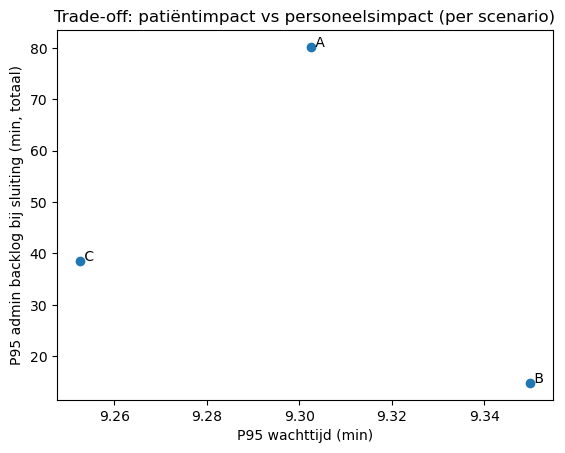

In [10]:
plot_tradeoff(df_report)


## 9. Appendix – Visualisaties

De appendix bevat twee duidelijk gescheiden sets visualisaties:

1. **Modelvalidatie**: ondersteunt dat de gekozen verdelingen/assumpties plausibel gedrag geven.
2. **Scenariovergelijking**: ondersteunt het vergelijken van A/B/C met dezelfde KPI’s.


### 9A. Modelvalidatie (gedrag van het model)

Doel: visueel checken dat wachttijden en consult-/adminvariatie zich gedragen zoals verwacht.
Deze figuren zijn bedoeld als sanity-check, niet als ‘bewijs’ voor absolute cijfers.


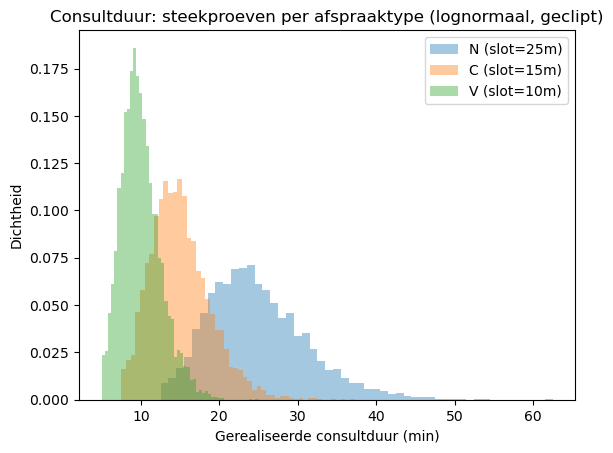

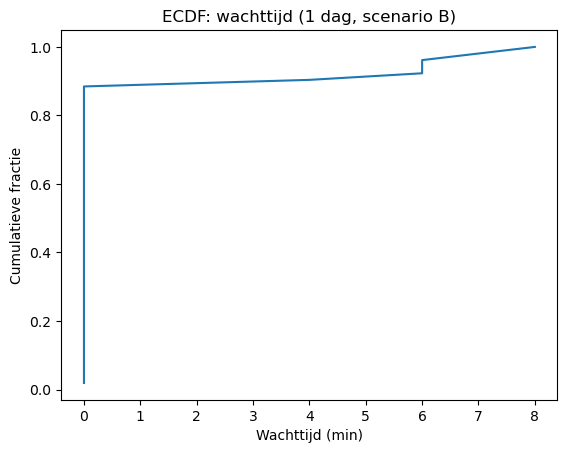

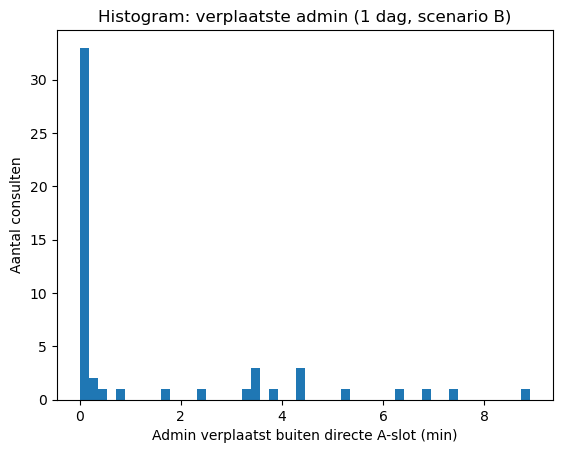

In [11]:

# ----------------------------
# 9A) Modelvalidatie visualisaties
# ----------------------------

def plot_consult_duration_samples(cfg: ModelConfig, *, n: int = 5000, seed: int = 7) -> None:
    """Laat de gerealiseerde consultduur zien t.o.v. planned slot (per type)."""
    rng = np.random.default_rng(seed)
    types = ["N", "C", "V"]
    plt.figure()
    for t in types:
        planned = cfg.slot_minutes[t]
        samples = np.array([realized_consult_minutes(cfg, rng, planned) for _ in range(n)], dtype=float)
        # Plot als histogram in dezelfde figuur; default colors zijn ok
        plt.hist(samples, bins=50, alpha=0.4, density=True, label=f"{t} (slot={planned}m)")
    plt.xlabel("Gerealiseerde consultduur (min)")
    plt.ylabel("Dichtheid")
    plt.title("Consultduur: steekproeven per afspraaktype (lognormaal, geclipt)")
    plt.legend()
    plt.show()


def plot_wait_ecdf_one_day(cfg: ModelConfig, *, seed: int = 7) -> None:
    """ECDF van wachttijd over alle consulten op één representatieve dag."""
    day = simulate_day(cfg, seed=seed)
    waits = []
    for res in day.values():
        for cw in res.consult_workability:
            waits.append(cw.wait_minutes)

    waits = np.array(waits, dtype=float)
    if len(waits) == 0:
        print("Geen consulten gevonden in deze simulatie-dag.")
        return

    x = np.sort(waits)
    y = np.arange(1, len(x) + 1) / len(x)

    plt.figure()
    plt.plot(x, y)
    plt.xlabel("Wachttijd (min)")
    plt.ylabel("Cumulatieve fractie")
    plt.title(f"ECDF: wachttijd (1 dag, scenario {cfg.scenario_name})")
    plt.show()


def plot_admin_displacement_hist_one_day(cfg: ModelConfig, *, seed: int = 7) -> None:
    """Histogram van verplaatste admin-minuten per consult op één dag."""
    day = simulate_day(cfg, seed=seed)
    displaced = []
    for res in day.values():
        for cw in res.consult_workability:
            displaced.append(cw.admin_displaced_minutes)

    displaced = np.array(displaced, dtype=float)
    plt.figure()
    plt.hist(displaced, bins=50)
    plt.xlabel("Admin verplaatst buiten directe A-slot (min)")
    plt.ylabel("Aantal consulten")
    plt.title(f"Histogram: verplaatste admin (1 dag, scenario {cfg.scenario_name})")
    plt.show()


# Run (voorbeeld: scenario B is vaak het meest 'representatief' voor werkbaarheid)
plot_consult_duration_samples(cfgB, n=5000, seed=7)
plot_wait_ecdf_one_day(cfgB, seed=7)
plot_admin_displacement_hist_one_day(cfgB, seed=7)


### 9B. Scenariovergelijking (A/B/C)

Doel: visueel ondersteunen hoe scenario’s verschillen op de gekozen KPI’s.
We tonen zowel **spreiding over dagen** (boxplots) als een **trade-off plot**.


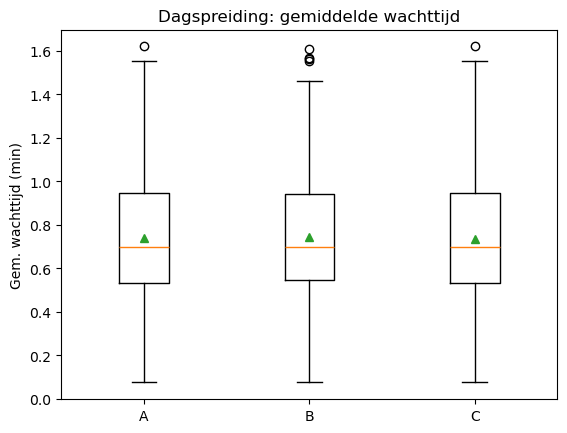

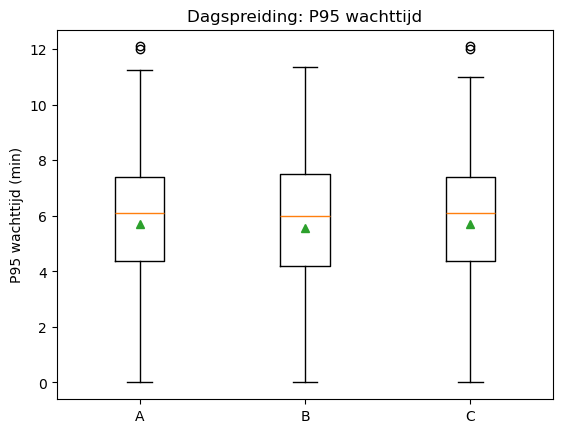

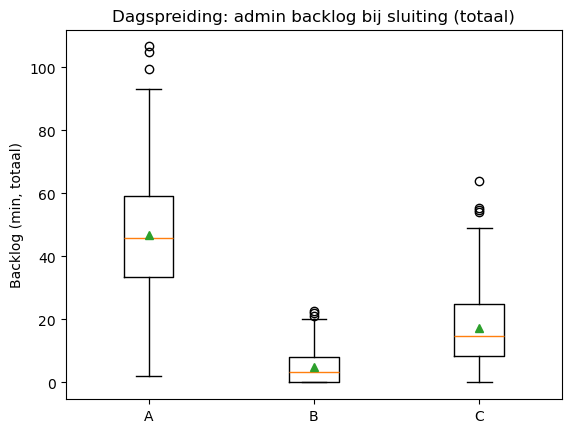

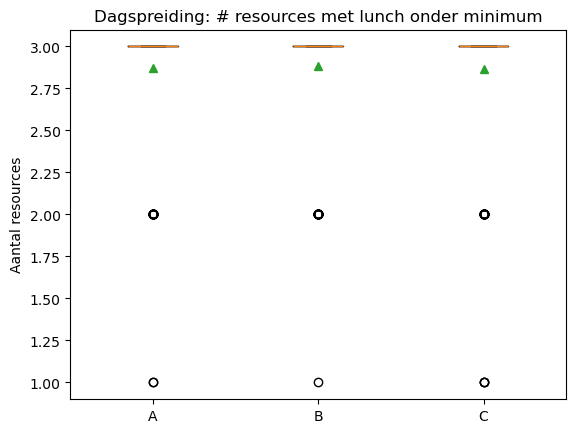

,scenario,Dagen,Gem. benutting consult (%),P95 benutting consult (%),Gem. benutting consult+admin binnen dag (%),P95 benutting consult+admin binnen dag (%)
0,A,300,60.3,67.0,78.0,85.0
1,B,300,56.9,61.7,76.1,81.3
2,C,300,60.3,66.9,79.8,87.0


In [13]:

# ----------------------------
# 9B) Scenariovergelijking visualisaties
# ----------------------------

def simulate_kpi_frames(cfgs: Dict[str, ModelConfig], *, n_days: int = 300, seed: int = 2026) -> pd.DataFrame:
    """Return lange tabel met per dag KPI's + scenario label."""
    frames = []
    for s, cfg in cfgs.items():
        df = simulate_many_days(cfg, n_days=n_days, seed=seed)
        df = df.copy()
        df["scenario"] = s
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def plot_box(df_long: pd.DataFrame, col: str, title: str, ylabel: str) -> None:
    """Boxplot per scenario voor een KPI."""
    order = ["A", "B", "C"]
    data = [df_long.loc[df_long["scenario"] == s, col].dropna().values for s in order]
    plt.figure()
    plt.boxplot(data, tick_labels=order, showmeans=True)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


# Simuleer KPI’s per dag voor A/B/C (zelfde seeds voor vergelijkbaarheid)
df_long = simulate_kpi_frames({"A": cfgA, "B": cfgB, "C": cfgC}, n_days=300, seed=2026)

plot_box(df_long, "avg_wait", "Dagspreiding: gemiddelde wachttijd", "Gem. wachttijd (min)")
plot_box(df_long, "p95_wait", "Dagspreiding: P95 wachttijd", "P95 wachttijd (min)")
plot_box(df_long, "admin_backlog_close_total", "Dagspreiding: admin backlog bij sluiting (totaal)", "Backlog (min, totaal)")
plot_box(df_long, "resources_lunch_below_min", "Dagspreiding: # resources met lunch onder minimum", "Aantal resources")

# Trade-off plot (zelfde als in hoofdtekst, maar herhaald hier niet nodig)
# plot_tradeoff(df_report)

# ----------------------------
# 9B) Benutting (utilization) per scenario
# ----------------------------

# ----------------------------
# 9B) Benutting (utilization) per scenario
# ----------------------------

def simulate_many_days_util(cfg: ModelConfig, *, n_days: int = 300, seed: int = 2026) -> pd.DataFrame:
    """
    Run n_days en retourneer per dag benuttings-KPI's.

    Definities:
    - util_clin_total: consultminuten / (werkminuten * aantal resources)
    - util_total_within_day: (consultminuten + admin binnen dag) / (werkminuten * aantal resources)
      -> admin na sluiting telt hier NIET mee (die is juist onderdeel van 'uitloop/werkdruk').
    """
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**31 - 1, size=n_days)

    work_minutes = cfg.day_end - cfg.day_start
    denom = work_minutes * len(cfg.resources)

    rows = []
    for s in seeds:
        day_results = simulate_day(cfg, seed=int(s))
        summ = summarize_day(cfg, day_results)

        total_consult = sum(summ[rid]["consult_minutes"] for rid in cfg.resources)
        total_admin_within = sum(summ[rid]["admin_done_within_day"] for rid in cfg.resources)

        util_clin_total = total_consult / denom if denom > 0 else 0.0
        util_total_within_day = (total_consult + total_admin_within) / denom if denom > 0 else 0.0

        rows.append({
            "util_clin_total": float(util_clin_total),
            "util_total_within_day": float(util_total_within_day),
        })

    return pd.DataFrame(rows)


def utilization_report(cfg: ModelConfig, *, n_days: int = 300, seed: int = 2026) -> Dict[str, float]:
    """Compacte scenario-samenvatting voor benutting."""
    dfu = simulate_many_days_util(cfg, n_days=n_days, seed=seed)

    return {
        "scenario": cfg.scenario_name,
        "n_days": int(n_days),
        "avg_util_clin_total": float(dfu["util_clin_total"].mean()),
        "p95_util_clin_total": float(dfu["util_clin_total"].quantile(0.95)),
        "avg_util_total_within_day": float(dfu["util_total_within_day"].mean()),
        "p95_util_total_within_day": float(dfu["util_total_within_day"].quantile(0.95)),
    }


df_util = pd.DataFrame([
    utilization_report(cfgA, n_days=300, seed=2026),
    utilization_report(cfgB, n_days=300, seed=2026),
    utilization_report(cfgC, n_days=300, seed=2026),
])

# Nettere presentatie (percentages)
df_util_fmt = df_util.copy()
for c in ["avg_util_clin_total", "p95_util_clin_total", "avg_util_total_within_day", "p95_util_total_within_day"]:
    df_util_fmt[c] = (df_util_fmt[c] * 100).round(1)

df_util_fmt = df_util_fmt.rename(columns={
    "avg_util_clin_total": "Gem. benutting consult (%)",
    "p95_util_clin_total": "P95 benutting consult (%)",
    "avg_util_total_within_day": "Gem. benutting consult+admin binnen dag (%)",
    "p95_util_total_within_day": "P95 benutting consult+admin binnen dag (%)",
    "n_days": "Dagen",
})

df_util_fmt
